# TP1

In [1]:
from src.utils import retrieve_patterns
from src.hopfield import Hopfield
from src.pattern import Pattern
from collections import defaultdict


patterns = defaultdict(list)
for pattern in retrieve_patterns("images"):
    patterns[len(pattern)].append(pattern)

models = {}
for size, ps in patterns.items():
    m = Hopfield(size)
    m.train_batch(ps)
    models[size] = m

## a) Verifique si la red aprendió las imágenes enseñadas

In [2]:
for size, m in models.items():
    ps = patterns[size]

    for p in ps:
        if not m.is_stable(p):
            raise Exception(f"network didn't learn pattern {p.name}")

Como el bloque no tira la excepción, sabemos que los modelos aprenden los patrones

## b) Evalúe la evolución de la red al presentarle versiones alteradas de las imágenes aprendidas: agregado de ruido, elementos borrados o agregados.

Se utilizará la distancia Hamming entre el patrón original y el patrón convergido para tener una noción de distancia. También se tendrá en cuenta la cantidad de iteraciónes necesarias para alcanzar la convergencia.

Las neuronas alteradas se eligen al azar, se escoge una permutación de ellas y luego hay k alteradas.

In [3]:
import matplotlib.pyplot as plt
from typing import Callable, Iterable
from math import sqrt


def converge_with(m: Hopfield, p: Pattern, f: Callable) -> tuple[int, int]:
    noisy = f(p)
    closest, steps = m.recall(noisy)
    dist = sum(int(closest[i] != p[i]) for i in range(len(p)))
    return steps, dist


def steps_dists_to_converge(size: int, ks: Iterable[int], f: Callable) -> tuple[list[float], list[float]]:
    ps = patterns[size]
    m = models[size]

    steps, dists = [], []

    for k in ks:
        k = min(k, size)
        steps_sum, dists_sum = 0, 0

        for p in ps:
            steps_taken, dist = converge_with(m, p, lambda x: f(x, k))
            steps_sum += steps_taken
            dists_sum += dist

        steps.append(steps_sum / len(ps))
        dists.append(dists_sum / len(ps))

    return steps, dists


def plot(size: int, f: Callable, xlabel: str):
    ks = list(range(0, size + 1, size // 10))
    steps, dists = steps_dists_to_converge(size, ks, flip_bytes)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(ks, dists)
    ax1.set_title(f"Mean distances to the original pattern")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Hamming distance (neurons)")

    ax2.plot(ks, steps)
    ax2.set_title(f"Mean steps to converge")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Steps taken to converge")

    fig.suptitle(f"Hopfield Network with {size} neurons", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### Neuronas invertidas

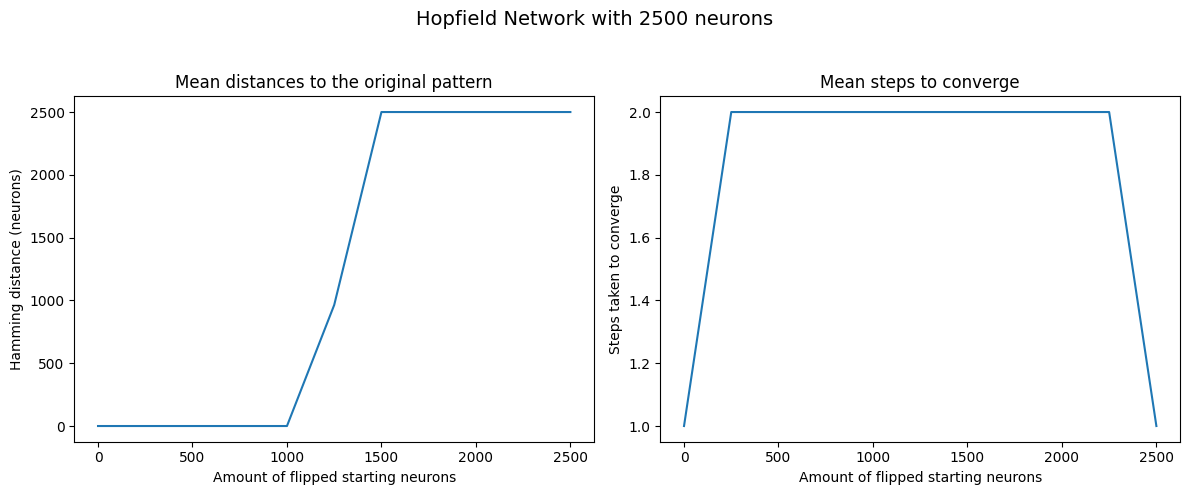

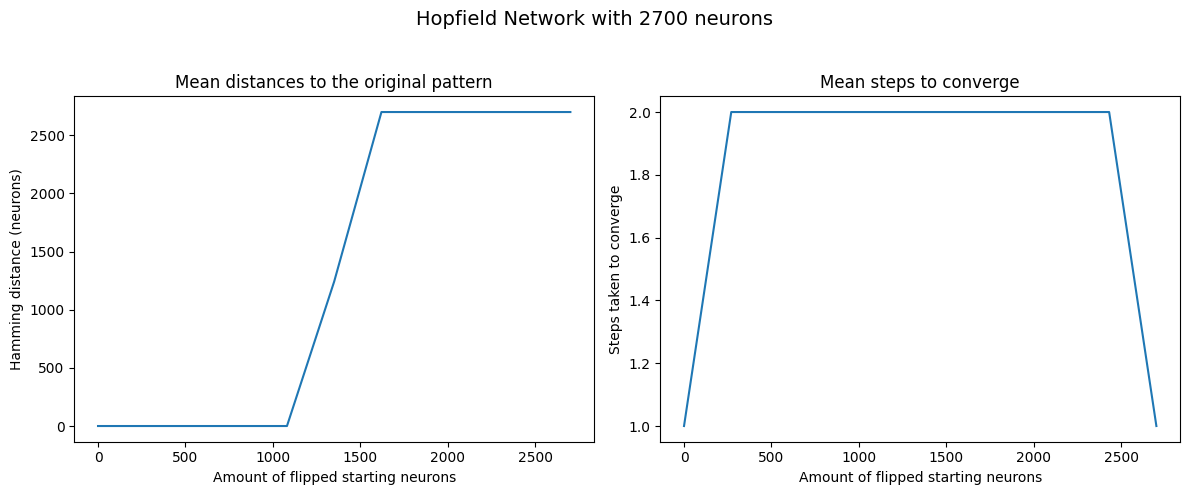

In [4]:
from src.utils import flip_bytes

for size in sorted(patterns):
    plot(size, flip_bytes, "Amount of flipped starting neurons")

#### Neuronas seteadas a 1

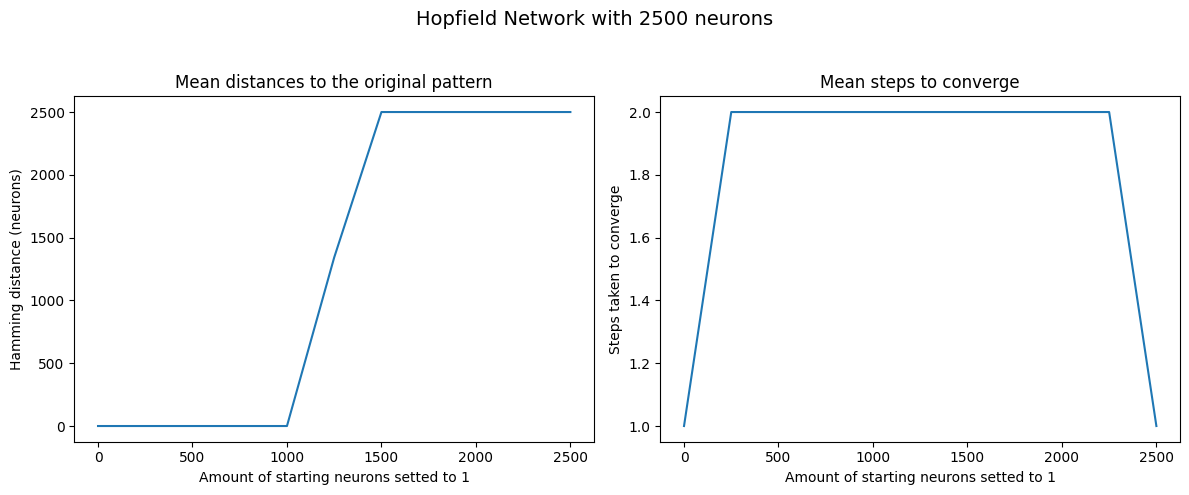

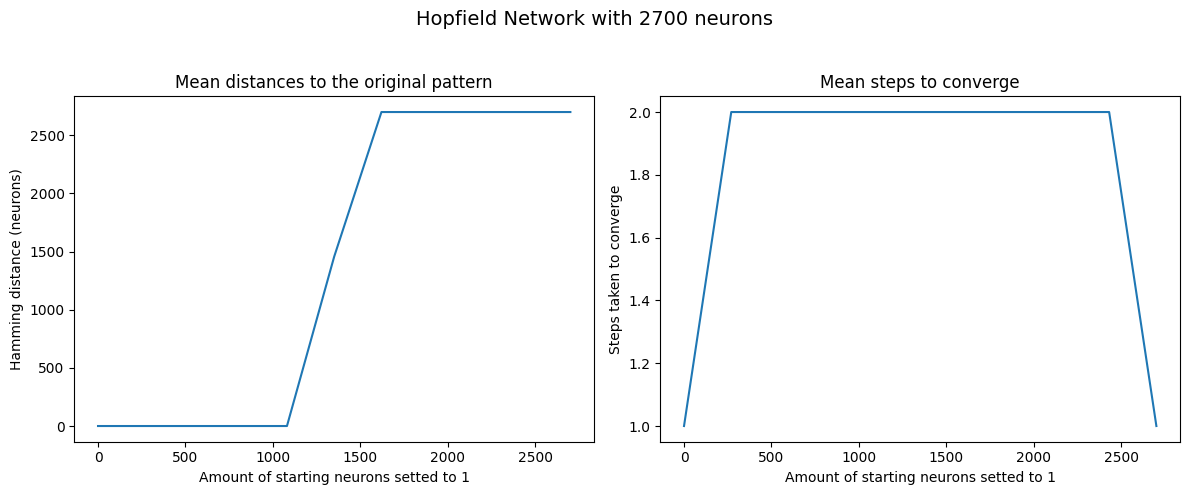

In [5]:
from src.utils import paint_bytes

for size in sorted(patterns):
    plot(size, lambda p, k: paint_bytes(p, k, 1), "Amount of starting neurons setted to 1")

#### Neuronas seteadas a -1

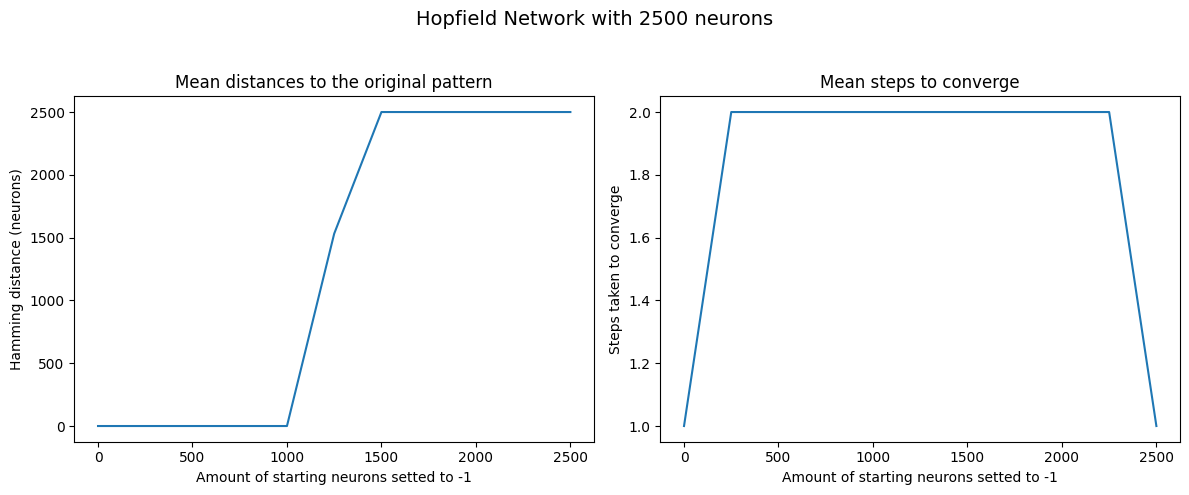

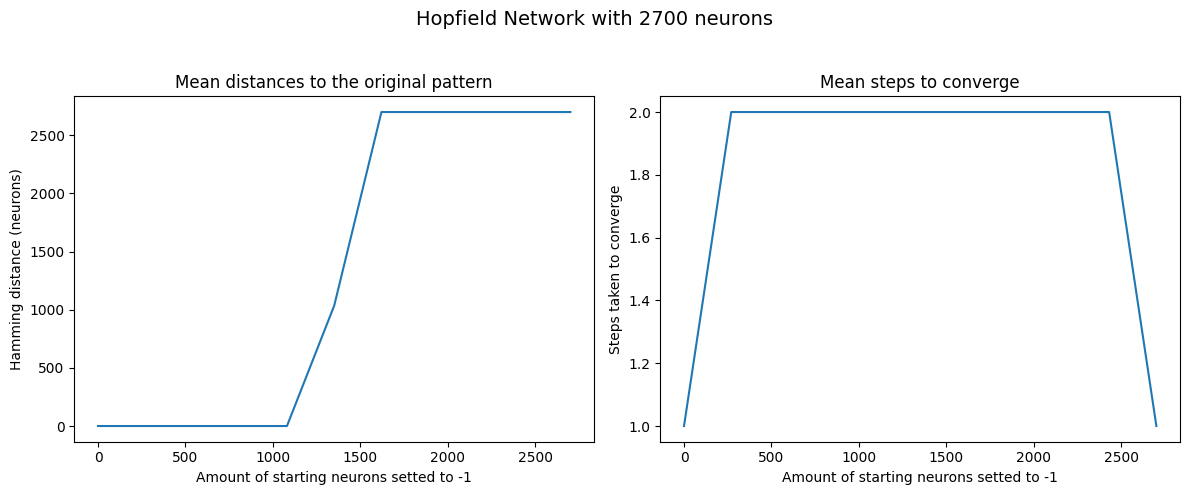

In [6]:
from src.utils import paint_bytes

for size in sorted(patterns):
    plot(size, lambda p, k: paint_bytes(p, k, -1), "Amount of starting neurons setted to -1")

## c) Evalúe la existencia de estados espurios en la red: patrones inversos y combinaciones de un número impar de patrones. (Ver Spurious States, en la sección 2.2, Hertz, Krogh & Palmer, pág. 24).

#### Patrones inversos

In [5]:
for size, m in models.items():
    ps = patterns[size]

    for p in ps:
        if not m.is_stable(-p):
            raise Exception(f"{p.name} is not a spurius state")

#### Combinaciones de un número impar de patrones

In [4]:
from src.utils import all_linear_combs

for size, m in models.items():
    combs = all_linear_combs(patterns[size])
    
    for p in combs:
        if not m.is_stable(p):
            raise Exception(f"{p.name} is not a spurius state")

## d) Realice un entrenamiento con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique